# O1: MPC mastery (concept + implementation)  

*   Understand MPC mathematically, practically, and statistically.
*   Know exactly how preprocessing choices (filter, Hilbert, phase unwrap, edge effects) change results.
*   Establish “MPC is high” ≠ “true coupling” unless confounds are ruled out

 These are the “characteristics” backed up with controlled experiments:

### A. Sample-size / window-length dependence

 For independent phases, MPC is not exactly 0; it has a finite-sample bias (shrinks ~ with longer windows).

 “For independent dynamics values of the mean phase coherence R go to zero only for N → ∞. However, in real-world data we never have an infinite number of data points. Therefore, we do not know which values of R to expect for independent dynamics.”

 **GOAL** I want to understand how MPC behaves when there is no true coupling, and how that depends on:

* window length (how many samples N you average over)
* the phase extraction pipeline (bandpass + Hilbert)

So I build two null models:

* Ideal null: phase differences are completely random and independent
* Practical null: two independent signals are processed the same way you process EEG (bandpass + Hilbert), then MPC is computed



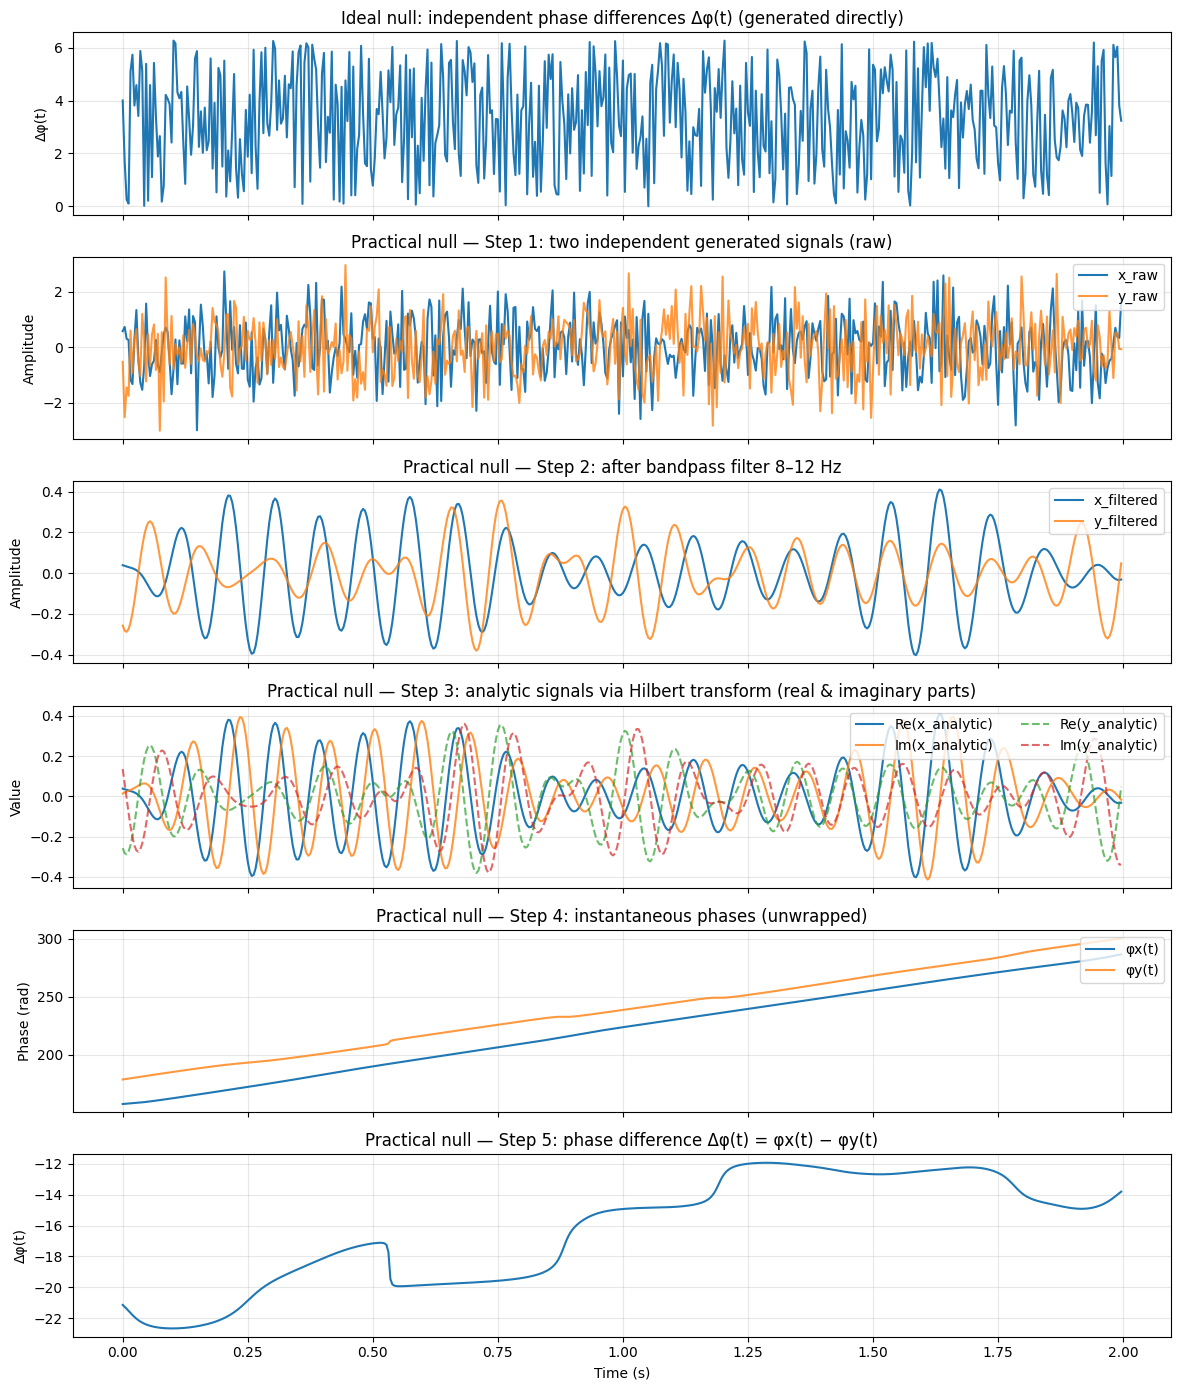

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

# ------------------- settings -------------------
rng = np.random.default_rng(0)

fs = 256
L = 2.0                     # seconds (window you want to show)
band = (8, 12)
order = 4
edge_trim_s = 1.0
extra_buffer_s = 2.0

N = int(L * fs)
t = np.arange(N) / fs

edge_trim = int(edge_trim_s * fs)
T_total = L + 2*edge_trim_s + extra_buffer_s
n_total = int(T_total * fs)

# ------------------- helpers -------------------
def bandpass_filter(x, fs, band=(8, 12), order=4):
    low, high = band
    sos = sg.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    return sg.sosfiltfilt(sos, x)

def analytic_signal(x_filt):
    return sg.hilbert(x_filt)

def phase_from_analytic(xa):
    return np.unwrap(np.angle(xa))

# ============================================================
# 1) IDEAL NULL EXAMPLE: directly generate independent phase differences
# ============================================================
dphi_iid = rng.uniform(0, 2*np.pi, size=N)

# ============================================================
# 2) PRACTICAL NULL: independent signals -> filter -> Hilbert -> phase -> phase difference
# ============================================================

# Generate independent raw signals (noise)
x_raw = rng.standard_normal(n_total)
y_raw = rng.standard_normal(n_total)

# Bandpass filter
x_filt = bandpass_filter(x_raw, fs, band=band, order=order)
y_filt = bandpass_filter(y_raw, fs, band=band, order=order)

# Analytic signals via Hilbert
x_ana = analytic_signal(x_filt)
y_ana = analytic_signal(y_filt)

# Instantaneous phases (unwrapped)
phx = phase_from_analytic(x_ana)
phy = phase_from_analytic(y_ana)

# Trim edges to reduce boundary artefacts (do it for all representations)
sl = slice(edge_trim, -edge_trim)

x_raw_t = x_raw[sl]
y_raw_t = y_raw[sl]
x_filt_t = x_filt[sl]
y_filt_t = y_filt[sl]
x_ana_t = x_ana[sl]
y_ana_t = y_ana[sl]
phx_t = phx[sl]
phy_t = phy[sl]

# Pick one window (same window for everything)
max_start = len(x_raw_t) - N
start = rng.integers(0, max_start)
win = slice(start, start + N)

x_raw_w = x_raw_t[win]
y_raw_w = y_raw_t[win]
x_filt_w = x_filt_t[win]
y_filt_w = y_filt_t[win]
x_ana_w = x_ana_t[win]
y_ana_w = y_ana_t[win]
phx_w = phx_t[win]
phy_w = phy_t[win]

dphi_practical = phx_w - phy_w

# ============================================================
# 3) VISUALIZATION: full pipeline
# ============================================================

fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

# (A) Ideal null: phase difference
axes[0].plot(t, dphi_iid)
axes[0].set_title("Ideal null: independent phase differences Δφ(t) (generated directly)")
axes[0].set_ylabel("Δφ(t)")
axes[0].grid(True, alpha=0.3)

# (B) Practical null: raw signals
axes[1].plot(t, x_raw_w, label="x_raw")
axes[1].plot(t, y_raw_w, label="y_raw", alpha=0.8)
axes[1].set_title("Practical null — Step 1: two independent generated signals (raw)")
axes[1].set_ylabel("Amplitude")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# (C) Practical null: filtered signals
axes[2].plot(t, x_filt_w, label="x_filtered")
axes[2].plot(t, y_filt_w, label="y_filtered", alpha=0.8)
axes[2].set_title(f"Practical null — Step 2: after bandpass filter {band[0]}–{band[1]} Hz")
axes[2].set_ylabel("Amplitude")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

# (D) Practical null: analytic signals (Hilbert) shown as real & imaginary parts
axes[3].plot(t, np.real(x_ana_w), label="Re(x_analytic)")
axes[3].plot(t, np.imag(x_ana_w), label="Im(x_analytic)", alpha=0.8)
axes[3].plot(t, np.real(y_ana_w), label="Re(y_analytic)", linestyle="--", alpha=0.7)
axes[3].plot(t, np.imag(y_ana_w), label="Im(y_analytic)", linestyle="--", alpha=0.7)
axes[3].set_title("Practical null — Step 3: analytic signals via Hilbert transform (real & imaginary parts)")
axes[3].set_ylabel("Value")
axes[3].legend(loc="upper right", ncols=2)
axes[3].grid(True, alpha=0.3)

# (E) Practical null: phases
axes[4].plot(t, phx_w, label="φx(t)")
axes[4].plot(t, phy_w, label="φy(t)", alpha=0.8)
axes[4].set_title("Practical null — Step 4: instantaneous phases (unwrapped)")
axes[4].set_ylabel("Phase (rad)")
axes[4].legend(loc="upper right")
axes[4].grid(True, alpha=0.3)

# (F) Practical null: phase difference
axes[5].plot(t, dphi_practical)
axes[5].set_title("Practical null — Step 5: phase difference Δφ(t) = φx(t) − φy(t)")
axes[5].set_ylabel("Δφ(t)")
axes[5].set_xlabel("Time (s)")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


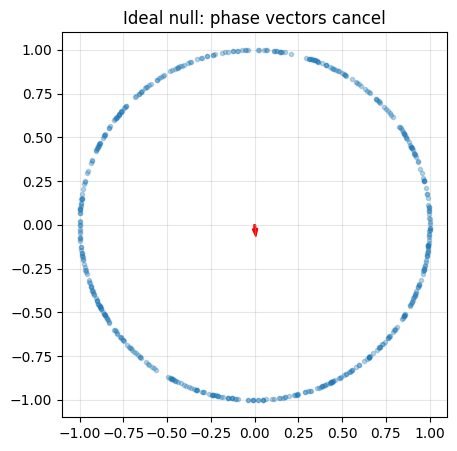

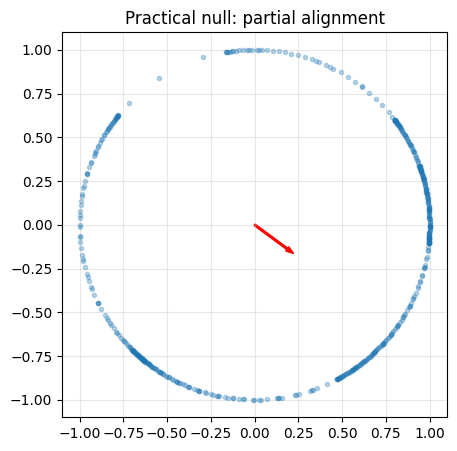

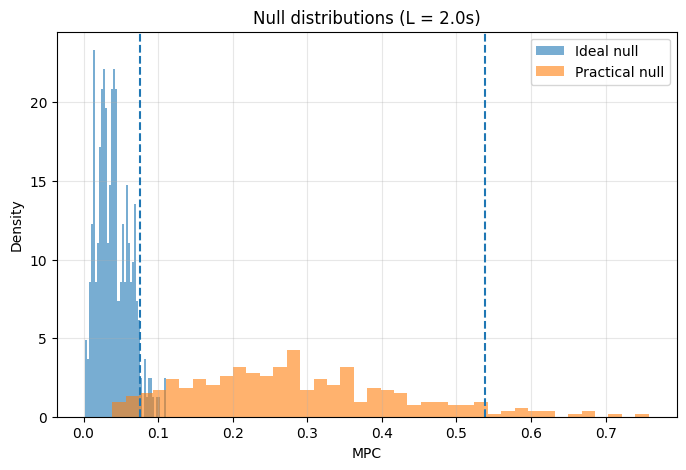

In [ ]:
def plot_phase_vectors(dphi, title):
    z = np.exp(1j * dphi)
    mean_z = np.mean(z)

    fig, ax = plt.subplots(figsize=(5,5))
    ax.plot(np.real(z), np.imag(z), '.', alpha=0.3)
    ax.arrow(0, 0, np.real(mean_z), np.imag(mean_z),
             width=0.01, color='red', length_includes_head=True)
    ax.set_aspect('equal')
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.show()

plot_phase_vectors(dphi_iid, "Ideal null: phase vectors cancel")
plot_phase_vectors(dphi_practical, "Practical null: partial alignment")

L = 2.0

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.hist(results_iid[L], bins=40, density=True, alpha=0.6, label="Ideal null")
ax.hist(results_hilb[L], bins=40, density=True, alpha=0.6, label="Practical null")

ax.axvline(np.quantile(results_iid[L], 0.95), linestyle="--")
ax.axvline(np.quantile(results_hilb[L], 0.95), linestyle="--")

ax.set_xlabel("MPC")
ax.set_ylabel("Density")
ax.set_title(f"Null distributions (L = {L}s)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


This plot shows that “high MPC” can arise purely from the phase-extraction pipeline, even when signals are completely independent, therefore MPC must always be interpreted relative to an appropriate null distribution.

But this plot shows:

MPC = 0.4 is:
* impossible under ideal i.i.d. phases
* perfectly normal after bandpass + Hilbert

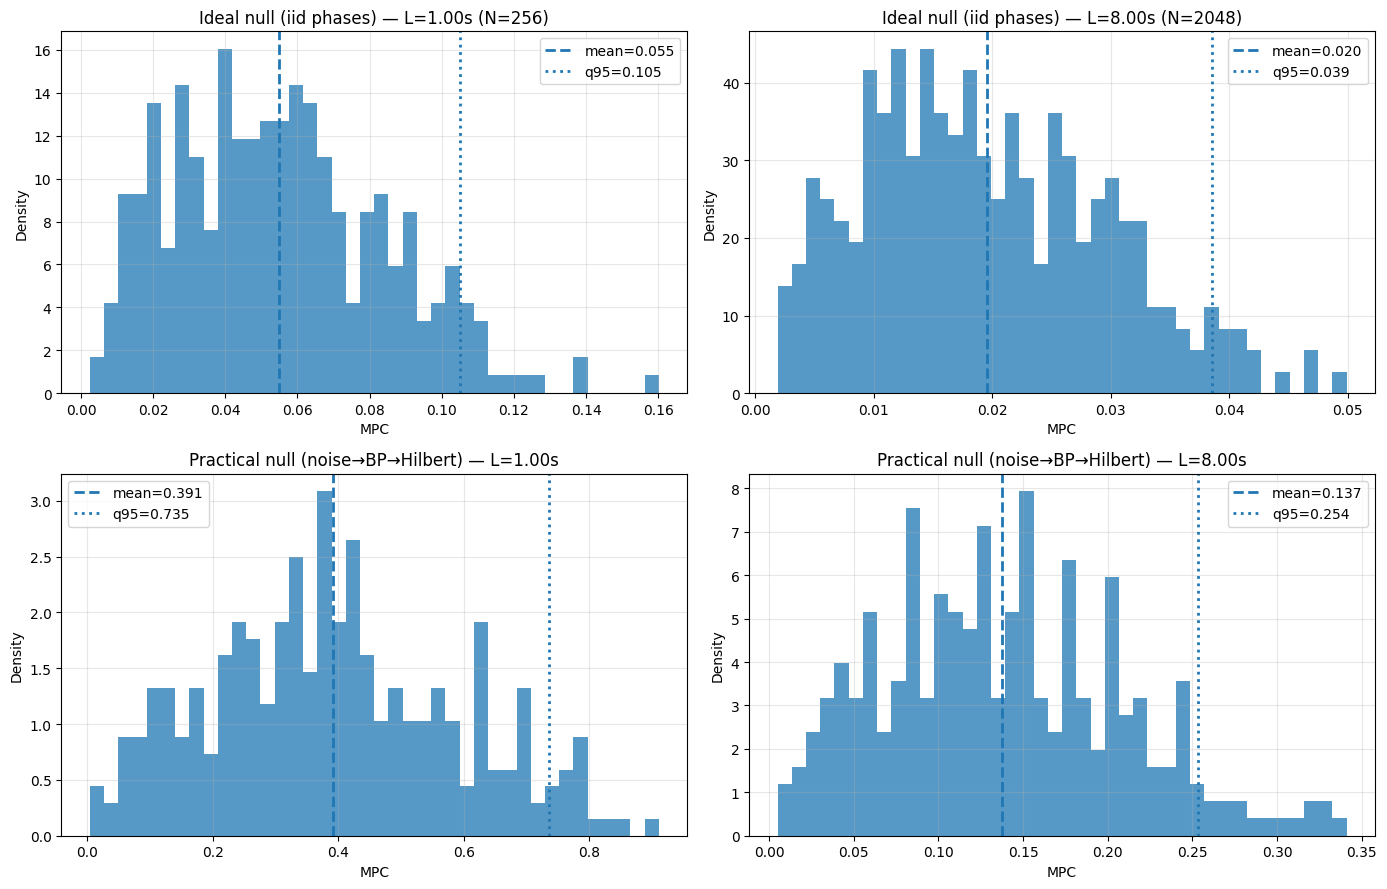

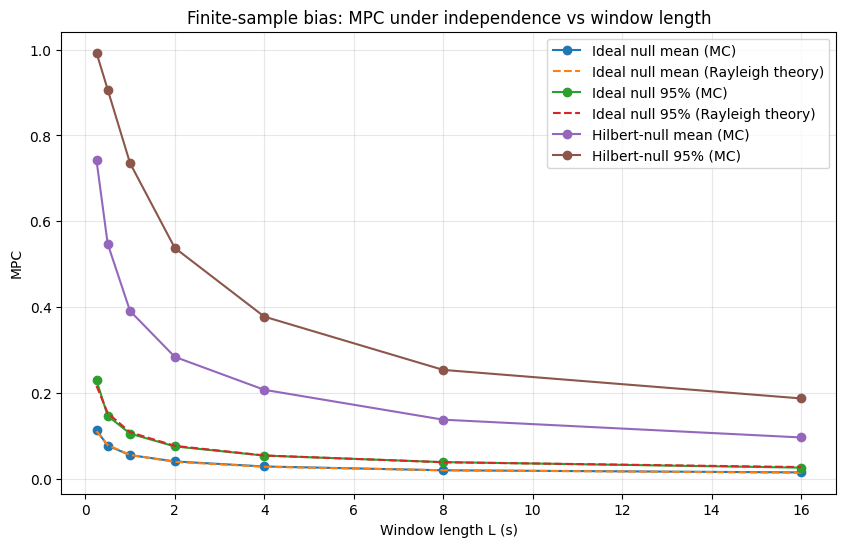

Null MPC thresholds (95th percentile):
  L= 0.25s | Ideal iid q95=0.2291 | Hilbert-null q95=0.9928
  L= 0.50s | Ideal iid q95=0.1464 | Hilbert-null q95=0.9068
  L= 1.00s | Ideal iid q95=0.1050 | Hilbert-null q95=0.7353
  L= 2.00s | Ideal iid q95=0.0751 | Hilbert-null q95=0.5379
  L= 4.00s | Ideal iid q95=0.0538 | Hilbert-null q95=0.3777
  L= 8.00s | Ideal iid q95=0.0386 | Hilbert-null q95=0.2535
  L=16.00s | Ideal iid q95=0.0257 | Hilbert-null q95=0.1870


In [5]:
# ============================================================
# O1.A — Fast version: Null MPC vs window length
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

rng = np.random.default_rng(0)

# ------------------- settings -------------------
fs = 256
window_lengths_s = np.array([0.25, 0.5, 1, 2, 4, 8, 16])
band = (8, 12)
order = 4

# practical-null settings (tune these if needed)
n_reps = 300          # 300 already gives stable curves, number of repeated simulations per window length
edge_trim_s = 1.0     # throw away 1 second at each edge after filtering to reduce boundary artefacts.
edge_trim = int(edge_trim_s * fs) # extra time added so filtering/hilbert has “space” and I can sample random windows safely

# extra padding for stable filtfilt + random start selection
extra_buffer_s = 2.0

# ------------------- helpers -------------------
def mpc_from_dphi(dphi):
    """Compute MPC from phase differences
    dphi: (..., N) array of phase differences"""
    return np.abs(np.mean(np.exp(1j * dphi), axis=-1))

def rayleigh_mean_plv(N):
  """
  theoretical predictions for the mean and 95th percentile of MPC if:
- the phase differences are i.i.d. uniform random
- and you average over N independent samples
This is purely a reference curve to show the finite-N bias effect.
  """
    # If dphi iid uniform => PLV ~ Rayleigh(sigma=1/sqrt(2N))
  sigma = 1 / np.sqrt(2 * N)
  return sigma * np.sqrt(np.pi / 2)

def rayleigh_q95_plv(N):
  sigma = 1 / np.sqrt(2 * N)
  return sigma * np.sqrt(-2 * np.log(1 - 0.95))

def bandpass_hilbert_phase_batch(X, fs, band, order=4):
    """
    Extract unwrapped Hilbert phase for a batch of signals
    X: (n_trials, n_samples)
    returns unwrapped phase: same shape
    """
    low, high = band
    sos = sg.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    Xf = sg.sosfiltfilt(sos, X, axis=1)     # batch filtfilt
    Xa = sg.hilbert(Xf, axis=1)             # batch hilbert
    phi = np.unwrap(np.angle(Xa), axis=1)   # unwrap along time
    return phi

# ------------------- 1) Ideal null (iid phases) -------------------
"""
Just random phase differences:
- For each window length L:
     1. compute number of samples: N = L*fs
     2. generate n_reps sets of independent random phase differences 𝜑(𝑡𝑗)∼U(0,2π)
     3. compute MPC (R) for each set

Output: results_iid[L] is an array of length n_reps

It is the distribution of MPC values under perfect independence for that window length.
"""
results_iid = {}
for L in window_lengths_s:
    N = int(L * fs)
    dphi = rng.uniform(0, 2*np.pi, size=(n_reps, N))
    results_iid[L] = mpc_from_dphi(dphi)

# ------------------- 2) Practical null (indep noise -> BP -> Hilbert) -------------------
"""
For each L I generate two independent signals per trial:
- X: white noise
- Y: independent white noise

Then for each:
    1. bandpass + Hilbert phase extraction → phX, phY
    2. trim edges (remove filter/hilbert boundary artefacts)
    3. for each trial, pick one random window of length N
    4. compute relative phase differences in that window:
    5. compute MPC (R) for that window
why?
Because after filtering + Hilbert:
- phase samples become autocorrelated
- effective number of independent samples is smaller
- MPC under independence can be larger than the ideal i.i.d. expectation

So this gives me a null distribution that is closer to preprocessing produces.

"""
results_hilb = {}

for L in window_lengths_s:
    N = int(L * fs)
    T_total = L + 2*edge_trim_s + extra_buffer_s
    n_total = int(T_total * fs)

    # Generate all trials at once
    X = rng.standard_normal((n_reps, n_total))
    Y = rng.standard_normal((n_reps, n_total))

    phX = bandpass_hilbert_phase_batch(X, fs, band, order=order)
    phY = bandpass_hilbert_phase_batch(Y, fs, band, order=order)

    # Trim edges (reduce boundary artefacts)
    phX = phX[:, edge_trim:-edge_trim]
    phY = phY[:, edge_trim:-edge_trim]

    # Choose one random contiguous window per trial
    max_start = phX.shape[1] - N
    starts = rng.integers(0, max_start, size=n_reps)

    # Gather windows efficiently
    idx = starts[:, None] + np.arange(N)[None, :]
    dphi_win = phX[np.arange(n_reps)[:, None], idx] - phY[np.arange(n_reps)[:, None], idx]

    results_hilb[L] = mpc_from_dphi(dphi_win)

# ------------------- 3) Visualizations -------------------
"""
Top row: MPC distributions for ideal null
Bottom row: MPC distributions for practical null
For each histogram, also plot:
 - dashed line: mean MPC
 - dotted line: 95th percentile MPC (a “null threshold”)

What the curves represent:
For each window length L, summarise the distributions by:
 - iid_mean[L]: average MPC under ideal null
 - iid_q95[L]: 95% threshold under ideal null
 - hilb_mean[L]: average MPC under practical null
 - hilb_q95[L]: 95% threshold under practical null
 - theory_*: theoretical reference curves for the ideal null

Then, plot these curves against L (log x-axis).

Why log x-axis?
Because L spans powers of two and the trend roughly follows a 1/sqrt𝑁-type shrinkage
If you average N random things, the typical size of the result goes down like:
1 divided by the square root of N
"""

# Histograms for two window lengths
L_show = [1.0, 8.0] if len(window_lengths_s) >= 2 else [window_lengths_s[0]]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, L in enumerate(L_show):
    ax = axes[i]
    vals = results_iid[L]
    N = int(L * fs)
    ax.hist(vals, bins=40, density=True, alpha=0.75)
    ax.axvline(np.mean(vals), linestyle="--", linewidth=2, label=f"mean={np.mean(vals):.3f}")
    ax.axvline(np.quantile(vals, 0.95), linestyle=":", linewidth=2, label=f"q95={np.quantile(vals,0.95):.3f}")
    ax.set_title(f"Ideal null (iid phases) — L={L:.2f}s (N={N})")
    ax.set_xlabel("MPC")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for i, L in enumerate(L_show):
    ax = axes[i+2]
    vals = results_hilb[L]
    N = int(L * fs)
    ax.hist(vals, bins=40, density=True, alpha=0.75)
    ax.axvline(np.mean(vals), linestyle="--", linewidth=2, label=f"mean={np.mean(vals):.3f}")
    ax.axvline(np.quantile(vals, 0.95), linestyle=":", linewidth=2, label=f"q95={np.quantile(vals,0.95):.3f}")
    ax.set_title(f"Practical null (noise→BP→Hilbert) — L={L:.2f}s")
    ax.set_xlabel("MPC")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Summary curves vs window length
Ls = window_lengths_s
iid_mean = np.array([results_iid[L].mean() for L in Ls])
iid_q95  = np.array([np.quantile(results_iid[L], 0.95) for L in Ls])

hilb_mean = np.array([results_hilb[L].mean() for L in Ls])
hilb_q95  = np.array([np.quantile(results_hilb[L], 0.95) for L in Ls])

N_vals = (Ls * fs).astype(int)
theory_mean = rayleigh_mean_plv(N_vals)
theory_q95  = rayleigh_q95_plv(N_vals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(Ls, iid_mean, marker="o", label="Ideal null mean (MC)")
ax.plot(Ls, theory_mean, linestyle="--", label="Ideal null mean (Rayleigh theory)")
ax.plot(Ls, iid_q95, marker="o", label="Ideal null 95% (MC)")
ax.plot(Ls, theory_q95, linestyle="--", label="Ideal null 95% (Rayleigh theory)")

ax.plot(Ls, hilb_mean, marker="o", label="Hilbert-null mean (MC)")
ax.plot(Ls, hilb_q95, marker="o", label="Hilbert-null 95% (MC)")

#ax.set_xscale("log")
ax.set_xlabel("Window length L (s)")
ax.set_ylabel("MPC")
ax.set_title("Finite-sample bias: MPC under independence vs window length")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("Null MPC thresholds (95th percentile):")
for L in Ls:
    print(f"  L={L:>5.2f}s | Ideal iid q95={np.quantile(results_iid[L],0.95):.4f} | Hilbert-null q95={np.quantile(results_hilb[L],0.95):.4f}")

**“If there is no coupling, what MPC values do I still get just because the window is finite?”**

* MPC has a finite-sample bias: even with totally independent phases, MPC > 0.

* This bias shrinks with longer windows.

So you can't interpret “MPC = 0.15” without knowing: window length, sampling and the preprocessing (which changes effective sample size).

“One cannot conclude from the mean phase coherence obtained for a pair of signals to a coupling between different brain areas… A common driving from an unmeasured source is only one of several possible reasons.”




* Each panel is a histogram of MPC values
* Each histogram comes from many repetitions of the same experiment

The only things that change are:
* top vs bottom → which null model
* left vs right → window length

Vertical lines:
 * dashed = mean MPC
+ dotted = 95th percentile (null threshold)

**Top-left panel**
Ideal null (i.i.d. phases), L = 1.0 s (N = 256)

* MPC values mostly between ~0.01 and ~0.10
* Mean ≈ 0.055
* 95th percentile ≈ 0.105

Even with perfect independence:
* MPC is not zero
* With only 256 samples, cancellation is incomplete
* Values up to ~0.1 are entirely normal

**Top-right panel**
Ideal null (i.i.d. phases), L = 8.0 s (N = 2048)
Only the window length increased (8× more samples)

* Histogram shifts left
* Mean ≈ 0.020
* 95th percentile ≈ 0.039

More samples → better cancellation ->
Finite-sample bias shrinks

**Bottom-left panel**
Practical null (noise → bandpass → Hilbert), L = 1.0 s

* MPC values now mostly between ~0.2 and ~0.6
* Mean ≈ 0.39
* 95th percentile ≈ 0.74

This is the crucial panel --> Nothing changed except how phase was obtained.

Yet:
* MPC values are much larger
* Some trials show MPC > 0.7
* There is still no coupling

Why?
* Filtering creates smooth oscillations
* Smooth phase → slow phase difference
* Slow Δφ → partial vector alignment
* Partial alignment → inflated MPC

“High MPC” can arise purely from the phase-extraction pipeline.

**Bottom-right panel**
Practical null (noise → bandpass → Hilbert), L = 8.0 s

* Histogram shifts left (again)
* Mean ≈ 0.137
* 95th percentile ≈ 0.254

Longer windows still reduce MPC But values remain far above the ideal null

Window length helps, but does not eliminate pipeline-induced bias.

SECOND FIGURE

All curves slope downward from left to right
→ As the window gets longer, MPC values drop.
→ Visually: longer averaging windows reduce apparent phase coherence.

The blue/green curves (ideal null) sit very close to the bottom of the plot
→ Independent phases produce small MPC values.
→ Even the 95% line stays near zero, especially for long windows.

The dashed theoretical lines lie almost on top of the solid ideal-null curves
→ What you simulate matches what theory predicts.
→ Visually confirms the ideal-null behavior is well understood and controlled.

The purple and brown curves (practical null) are much higher than the ideal-null curves
→ After filtering + Hilbert, MPC is visually inflated.
→ This separation is large and obvious at all window lengths.

At short windows (left side), the vertical gap between ideal and practical nulls is huge
→ Short windows + phase extraction create very large apparent MPC.
→ Visually: preprocessing dominates the result.

At long windows (right side), all curves move down but never meet
→ Increasing window length reduces MPC, but does not remove pipeline bias.
→ Practical null always remains well above ideal null.

The practical-null mean curve lies above the ideal-null 95% curve
→ Values that look “significant” under the ideal null are normal under the practical null.
→ Visually: one curve sits above another curve’s threshold.

The 95% curves always sit above their corresponding mean curves
→ The spread of MPC values is substantial, especially for the practical null.
→ Visually: distributions are broad, not tight.